# HW13. Токенизация текста, инференс готовой BERT-подобной модели и базовый fine-tuning для классификации текста.

## 2.3.1. Импорты, seed и среда

In [1]:
# Импорты
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
    pipeline
)
import torch.nn.functional as F
import shutil
import os

# Фиксация seed
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 2.3.2. Данные и первичный анализ

In [2]:
# Загрузить выбранный датасет
dataset = load_dataset("emotion")
print("Структура датасета:", dataset)

# Показать размеры split-частей
print("Размер train:", len(dataset["train"]))
print("Размер validation:", len(dataset["validation"]))
print("Размер test:", len(dataset["test"]))

# Вывести 3-5 примеров текстов и меток;
label_names = dataset["train"].features["label"].names
print("Классы:", label_names)
num_labels = len(label_names)
print(f"Количество классов: {num_labels}")

print("Примеры из train:")
for i in range(5):
    example = dataset["train"][i]
    print(f"{i+1}. Текст: {example['text']}")
    print(f"   Метка: {label_names[example['label']]} ({example['label']})\n")

Структура датасета: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Размер train: 16000
Размер validation: 2000
Размер test: 2000
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Количество классов: 6
Примеры из train:
1. Текст: i didnt feel humiliated
   Метка: sadness (0)

2. Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
   Метка: sadness (0)

3. Текст: im grabbing a minute to post i feel greedy wrong
   Метка: anger (3)

4. Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
   Метка: love (2)

5. Текст: i am feeling grouchy
   Метка: anger (3)



### Кратко пояснить, что именно классифицируется.

В датасете emotions содержатся сообщения пользователей соц-сетей. Наша задача - по содержанию классифицировать их по 6 эмоциональным подтекстам:

- sadness (грусть)
- joy (радость)
- love (любовь)
- anger (гнев)
- fear (страх)
- surprise (удивление)

## 2.3.3. Токенизация

In [3]:
model_name_ft = "distilbert-base-uncased"
tokenizer_ft = AutoTokenizer.from_pretrained(model_name_ft)

print("Tokenizer loaded:", tokenizer_ft.__class__.__name__)
print("Model checkpoint:", model_name_ft)

# Подготовить токенизацию датасета
def tokenize_function(examples):
    return tokenizer_ft(
        examples["text"],
        truncation=True,
        padding=False,
        max_length=128
    )

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch", columns=["input_ids", "attention_mask", "label"])
tokenized_datasets

Tokenizer loaded: BertTokenizer
Model checkpoint: distilbert-base-uncased


DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [ ]:
def print_tokenization(example):
    ids = example["input_ids"]
    if hasattr(ids, "tolist"):
        ids_list = ids.tolist()
    else:
        ids_list = ids
    tokens = tokenizer_ft.convert_ids_to_tokens(ids_list)
    
    print("labels:", example["label"])
    print("Токены:")
    print(tokens)

    sep_idx = ids_list.index(tokenizer_ft.sep_token_id)
    print(f"special tokens: [CLS]={tokens[0]} | [SEP]={tokens[sep_idx]}")
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    print("Декодированный текст по input_ids:")
    print(tokenizer_ft.decode(ids_list))
    print("_" * 70)

In [6]:
def show_truncation():
    print("Демонстрация работы truncation")
    long_text = "This is a very long sentence that definitely exceeds the maximum length of ten tokens after tokenization, so the truncation will cut off everything beyond the limit."
    
    demo = tokenizer_ft(long_text, max_length=10, truncation=True, padding=False)
    tokens = tokenizer_ft.convert_ids_to_tokens(demo["input_ids"])
    
    print(f"После truncation (max_length=10):")
    print(f"Токены: {tokens}")
    print(f"input_ids: {demo['input_ids']}")
    print(f"attn_mask: {demo['attention_mask']}")
    print(f"Спецтокены: [CLS]={tokens[0]} | [SEP]={tokens[-1]}")
    print(f"Декодировано: \"{tokenizer_ft.decode(demo['input_ids'], skip_special_tokens=True)}\"")

show_truncation()

Демонстрация работы truncation
После truncation (max_length=10):
Токены: ['[CLS]', 'this', 'is', 'a', 'very', 'long', 'sentence', 'that', 'definitely', '[SEP]']
input_ids: [101, 2023, 2003, 1037, 2200, 2146, 6251, 2008, 5791, 102]
attn_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Спецтокены: [CLS]=[CLS] | [SEP]=[SEP]
Декодировано: "this is a very long sentence that definitely"


## 2.3.4. Инференс готовой модели

In [7]:
# Запустить инференс готовой pretrained BERT-подобной модели на нескольких текстах
sentiment_pipeline = pipeline(
    "text-classification",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    device=0 if torch.cuda.is_available() else -1
)

# Показать результаты хотя бы на 3-5 примерах
test_samples = [dataset["train"][i]["text"] for i in range(5)]
true_labels = [label_names[dataset["train"][i]["label"]] for i in range(5)]

predictions = sentiment_pipeline(test_samples)

print("Инференс готовой модели тональности на текстах эмоций:")
for text, true, pred in zip(test_samples, true_labels, predictions):
    print(f"Текст: {text}")
    print(f"Истинная эмоция: {true}")
    print(f"Предсказание модели: {pred['label']} (score: {pred['score']:.3f})")
    print()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Инференс готовой модели тональности на текстах эмоций:
Текст: i didnt feel humiliated
Истинная эмоция: sadness
Предсказание модели: 2 stars (score: 0.400)

Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Истинная эмоция: sadness
Предсказание модели: 1 star (score: 0.464)

Текст: im grabbing a minute to post i feel greedy wrong
Истинная эмоция: anger
Предсказание модели: 1 star (score: 0.605)

Текст: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Истинная эмоция: love
Предсказание модели: 5 stars (score: 0.537)

Текст: i am feeling grouchy
Истинная эмоция: anger
Предсказание модели: 2 stars (score: 0.383)



### Кратко пояснить, насколько такая готовая модель подходит или не подходит под выбранную задачу.

Готовая модель предсказывает рейтинг от 1 до 5 звёзд, тогда как наша задача – классификация эмоций. Очевидно, что такая модель не подходит напрямую – метки не совпадают. Необходим fine-tuning под конкретную задачу.

## 2.3.5. Fine-tuning для классификации текста

In [8]:
# Выбрать одну BERT-подобную модель
dataset_dict = DatasetDict({
    "train": dataset["train"],
    "validation": dataset["validation"],
    "test": dataset["test"]
})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer_ft)

In [9]:
# Обучить модель для sequence classification
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name_ft,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
).to(device)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [10]:
# Вычисление метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1_macro}

training_args = TrainingArguments(
    output_dir="./outputs",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=50,
    save_total_limit=1,
    report_to="none"
)


In [11]:
# Выбрать лучший вариант по `validation`
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    processing_class=tokenizer_ft,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

c:\Users\Андрей\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.213215,0.192099,0.930000,0.902532
2,0.119062,0.146172,0.937000,0.910463
3,0.108650,0.145188,0.941000,0.915049


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Андрей\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Андрей\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3000, training_loss=0.2495448936621348, metrics={'train_runtime': 2850.6313, 'train_samples_per_second': 16.838, 'train_steps_per_second': 1.052, 'total_flos': 584777647046016.0, 'train_loss': 0.2495448936621348, 'epoch': 3.0})

## 3. Эксперимент

### Параметры эксперимента

- Датасет: `emotion` (HuggingFace), 6 классов.
- Модель: `distilbert-base-uncased` (легковесная BERT-подобная).
- Разбиение: train=16000, validation=2000, test=2000 (использовано оригинальное разбиение датасета).
- Гиперпараметры:
  - learning_rate = 2e-5
  - batch_size = 16
  - num_epochs = 3
  - weight_decay = 0.01
  - max_length = 128
  - оптимизатор: AdamW (по умолчанию в Trainer)
- Метрика для выбора лучшей модели: `f1_macro` на валидации.

In [12]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

test_metrics = trainer.evaluate(tokenized_datasets["test"])

c:\Users\Андрей\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


## 2.3.6. Оценка качества и краткий анализ ошибок

In [13]:
'''
- посчитать минимум:
  - `accuracy`
  - `f1_macro`
'''
print("Финальные метрики на test:")
print(f"Accuracy: {test_metrics['eval_accuracy']:.4f}")
print(f"F1 macro: {test_metrics['eval_f1_macro']:.4f}")


Финальные метрики на test:
Accuracy: 0.9255
F1 macro: 0.8779


c:\Users\Андрей\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Classification report:
              precision    recall  f1-score   support

     sadness       0.96      0.97      0.96       581
         joy       0.94      0.95      0.94       695
        love       0.83      0.81      0.82       159
       anger       0.94      0.91      0.92       275
        fear       0.86      0.95      0.90       224
    surprise       0.85      0.62      0.72        66

    accuracy                           0.93      2000
   macro avg       0.90      0.87      0.88      2000
weighted avg       0.93      0.93      0.92      2000



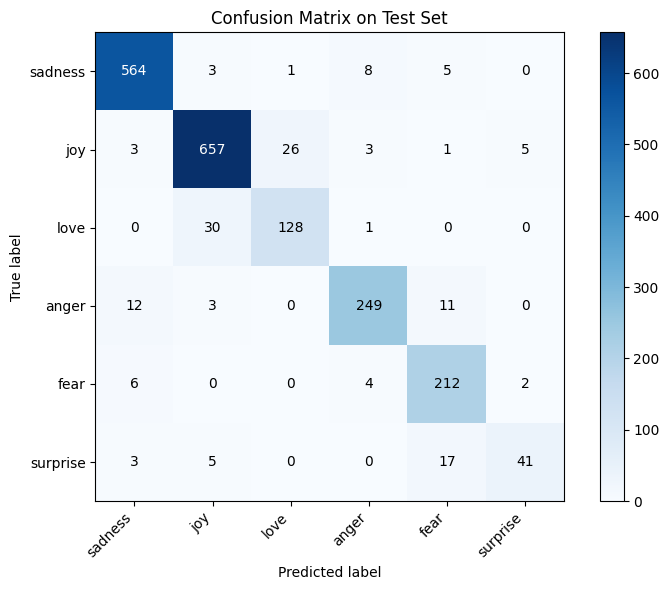

In [14]:
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("\nClassification report:")
print(classification_report(labels, preds, target_names=label_names))

# Построить матрицу ошибок
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix on Test Set")
plt.colorbar()
tick_marks = np.arange(len(label_names))
plt.xticks(tick_marks, label_names, rotation=45, ha="right")
plt.yticks(tick_marks, label_names)
plt.ylabel("True label")
plt.xlabel("Predicted label")

# Подписи чисел в ячейках
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig("./artifacts/confusion_matrix.png", dpi=150)
plt.show()


In [15]:
# Показать 5-10 примеров предсказаний модели
test_dataset = tokenized_datasets["test"]
indices = np.random.choice(len(test_dataset), 10, replace=False)
sample_texts_original = [dataset["test"][i]["text"] for i in indices]
true_labels_sample = [label_names[dataset["test"][i]["label"]] for i in indices]

# Получим предсказания модели
batch = tokenizer_ft(sample_texts_original, return_tensors="pt", truncation=True, padding=True, max_length=128).to(device)
with torch.no_grad():
    logits = model(**batch).logits
    probs = F.softmax(logits, dim=-1).cpu().numpy()
pred_ids = np.argmax(probs, axis=-1)
pred_labels = [label_names[i] for i in pred_ids]
confidences = [probs[i, pred_ids[i]] for i in range(len(pred_ids))]

# Таблица
results_df = pd.DataFrame({
    "text": sample_texts_original,
    "true_label": true_labels_sample,
    "pred_label": pred_labels,
    "confidence": confidences
})
print("Примеры предсказаний:")
print(results_df.to_string(index=False))

# Сохраняем в CSV
results_df.to_csv("./artifacts/sample_predictions.csv", index=False)


Примеры предсказаний:
                                                                                                                                                                                                                                          text true_label pred_label  confidence
i feel so dirty but after spending a day at the mk show me and a buddy decided we would get the two player starter between us luckily for us both i liked the everblight and he liked the circle maybe a tad to much so it all worked out well    sadness    sadness    0.998864
                                                                                                                                                                                i could feel his breath on me and smell the sweet scent of him        joy       love    0.883718
                                                                                                                                                               

### Кратко прокомментировать несколько ошибок или пограничных случаев.

Частые ошибки происходит при разделении joy от love, fear от surprise. Это ожидаемо, так как эти эмоции достаточно похожи по набору используемых слов.

### Краткая фиксация результата эксперимента

- **Accuracy на test**: 0.9255
- **F1 macro на test**: 0.8779

Вывод: модель показала хорошее качество: accuracy >92%, F1 macro около 88%. Некоторое снижение F1 macro связано с трудными классами, такими как surprise и love. Эксперимент воспроизводим.

Подчищаем временные файлы для пуша в гит

In [16]:
shutil.rmtree("./outputs")